# Qwen P2 — direction loudness per layer

Which layer is most direction-loaded, over the whole dataset. The answer pins
`--select-candidate-layers` for the selecting gather that follows.

Input is what `wrappers/qwen_analysis/loudest_layer/join_loudness_profile.sh` writes: one
row per reasoning token, one `L{layer}` column per layer, each cell `log P(any direction
word)` at that (token, layer).

An **empty** cell means the lens did not cover that layer (the jlens outside its fitted
range) — not "no mass here". It becomes `NaN` and is skipped by the mean, which is the
intended behaviour; a layer's mean is over the tokens it actually covers.

In [1]:
# 1. imports and load the joined tables
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUT_DIR = Path("/workspace/loudness_evaluation/qwen_p2_layer_profile")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# keep_default_na=False: decoded tokens include the literal string "NA" and empty
# strings, which pandas would otherwise turn into missing values.
jlens = pd.read_csv(OUT_DIR / "jlens_tokens.csv", keep_default_na=False, low_memory=False)
logitlens = pd.read_csv(OUT_DIR / "logitlens_tokens.csv", keep_default_na=False, low_memory=False)

print(f"jlens:     {len(jlens):,} token rows, {jlens.trajectory.nunique():,} trajectories")
print(f"logitlens: {len(logitlens):,} token rows, {logitlens.trajectory.nunique():,} trajectories")
jlens.head()

jlens:     1,841,963 token rows, 549 trajectories
logitlens: 1,841,963 token rows, 549 trajectories


,trajectory,size,complexity,run,step,reasoning_pos,abs_pos,token,agent_action,L3,L7,L11,L15,L19,L23,L27,L31,L35,L39
0,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,4,551,Ġto,DOWN,-5.470579,-5.892907,-6.169158,-6.374704,-6.417462,-7.075028,-7.241547,-7.568947,-8.048303,-10.241206
1,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,14,561,Ġgrid,DOWN,-6.035651,-5.960261,-6.093688,-6.000197,-6.052806,-6.446935,-6.643775,-7.873644,-7.096058,-9.005816
2,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,19,566,Ġa,DOWN,-5.164000,-5.121111,-6.098409,-6.048641,-6.209772,-6.611053,-6.927049,-12.116003,-15.155146,-12.314903
3,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,33,580,Ġgrid,DOWN,-6.089643,-6.084640,-6.308140,-6.454103,-6.429008,-6.820289,-7.382104,-7.933986,-8.468420,-10.627562
4,together_ai_gsarti_qwen3_6-35b_size11_comp0.0_156,11,0.0,156,0,35,582,Ġ,DOWN,-3.930382,-4.784491,-4.995828,-5.043641,-5.332113,-5.750499,-6.720715,-5.851019,-5.059235,-11.895891


In [2]:
# 2. aggregate at row level — every token is one observation
def layer_columns(df):
    """The L{layer} columns, in layer order."""
    cols = [c for c in df.columns if c.startswith("L") and c[1:].isdigit()]
    return sorted(cols, key=lambda c: int(c[1:]))


def loudness_matrix(df):
    """Just the layer columns, numeric. Empty cells (layer not covered) become NaN."""
    cols = layer_columns(df)
    return df[cols].apply(pd.to_numeric, errors="coerce")


jlens_mass = loudness_matrix(jlens)
logitlens_mass = loudness_matrix(logitlens)

print("layers:", [int(c[1:]) for c in layer_columns(jlens)])
print(f"jlens rows: {len(jlens_mass):,}   logitlens rows: {len(logitlens_mass):,}")

layers: [3, 7, 11, 15, 19, 23, 27, 31, 35, 39]
jlens rows: 1,841,963   logitlens rows: 1,841,963


In [3]:
# 3. mean direction loudness per layer
def mean_per_layer(mass):
    """{layer: mean loudness}, as a Series indexed by integer layer."""
    means = mass.mean()  # skips NaN
    means.index = [int(c[1:]) for c in means.index]
    return means.sort_index()


jlens_per_layer = mean_per_layer(jlens_mass)
logitlens_per_layer = mean_per_layer(logitlens_mass)

print(f"jlens argmax layer:     {jlens_per_layer.idxmax()}  ({jlens_per_layer.max():.4f})")
print(f"logitlens argmax layer: {logitlens_per_layer.idxmax()}  ({logitlens_per_layer.max():.4f})")
pd.DataFrame({"jlens": jlens_per_layer, "logitlens": logitlens_per_layer})

jlens argmax layer:     27  (-5.2489)
logitlens argmax layer: 38  (-5.6845)


,jlens,logitlens
0,NaN,-6.003466
1,NaN,-6.021075
2,NaN,-6.014893
3,-5.804833,-6.022461
4,NaN,-6.028795
5,NaN,-6.037340
6,NaN,-6.047695
7,-5.681973,-6.019542
8,NaN,-6.044072
9,NaN,-6.080082


saved /workspace/loudness_evaluation/qwen_p2_layer_profile/figures/jlens_loudness_per_layer.png


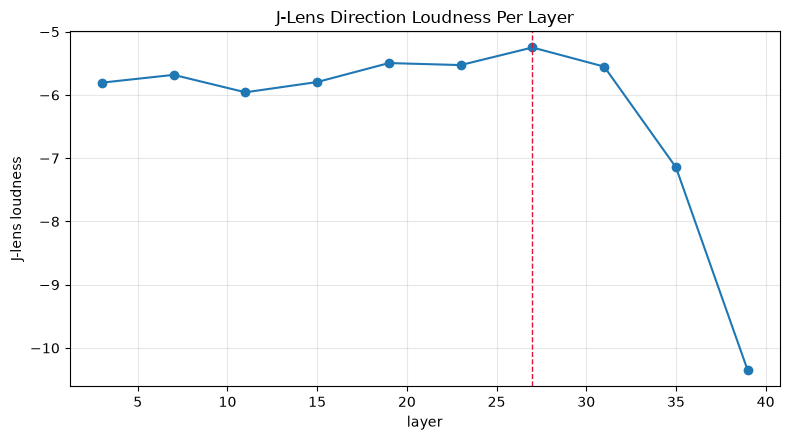

In [4]:
# 4. J-Lens Direction Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(jlens_per_layer.index, jlens_per_layer.values, marker="o")
ax.axvline(jlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("J-Lens Direction Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("J-lens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "jlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "jlens_loudness_per_layer.png")
plt.show()

saved /workspace/loudness_evaluation/qwen_p2_layer_profile/figures/logitlens_loudness_per_layer.png


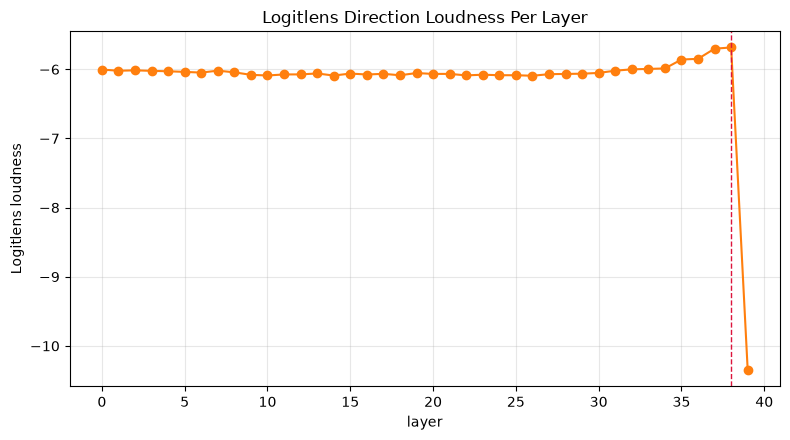

In [5]:
# 5. Logitlens Direction Loudness Per Layer
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(logitlens_per_layer.index, logitlens_per_layer.values, marker="o", color="tab:orange")
ax.axvline(logitlens_per_layer.idxmax(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("Logitlens Direction Loudness Per Layer")
ax.set_xlabel("layer")
ax.set_ylabel("Logitlens loudness")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "logitlens_loudness_per_layer.png", dpi=160, bbox_inches="tight")
print("saved", FIG_DIR / "logitlens_loudness_per_layer.png")
plt.show()